# 02 · Technology & materials

A **technology** is the other half of a simulation (the layout is the first):
the vertical layer stack and the **material** on each layer. gds_fdtd uses one
YAML for *every* engine — each material carries a neutral refractive index, an
optional [refractiveindex.info](https://refractiveindex.info) reference, and
optional per-engine hints (`tidy3d_db`, `lum_db`).

This notebook checks whether a real dispersive material, fed into a simulation,
matches the model the engine ships. It does, to within a few parts in
ten-thousand; where it wouldn't, the mismatch points to a specific fab process.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from gds_fdtd.grid import resolve_index
from gds_fdtd.materials.rii import load_rii_material
from gds_fdtd.plotting import plot_tech_stack
from gds_fdtd.technology import Technology


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)


tech = Technology.from_yaml(_find("examples/tech.yaml"))
RII_DB = _find("examples/02_technology/rii_db")
WL = np.linspace(1.5, 1.6, 11)  # telecom band

## 1 · The stack

The technology places each material in `z` with its index. Here: a silicon
core on oxide, oxide cladding. The substrate material in this file pins
`source: rii`, so every engine models the buried oxide from the same
refractiveindex.info page — `02b` walks through that mechanism.

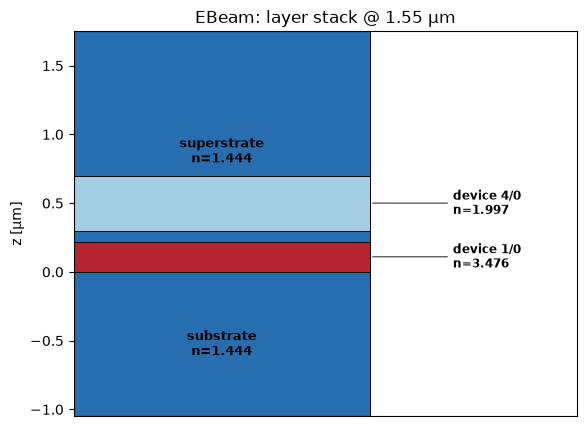

In [2]:
plot_tech_stack(tech, wavelength_um=1.55)
plt.show()

## 2 · refractiveindex.info vs the engines' own models

[refractiveindex.info](https://refractiveindex.info) is the community database
of measured optical constants. gds_fdtd reads it directly (`materials.rii`).
The FDTD engines each **ship their own** material models too. If both describe
the same physics, they should agree — so we overlay them.

We compare three workhorse silicon-photonics materials, each from a real
refractiveindex.info page against the matching tidy3d built-in model.

17:18:20 PDT WARNING: Using canonical configuration directory at                
             '/home/mustafa/.config/tidy3d'. Found legacy directory at          
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

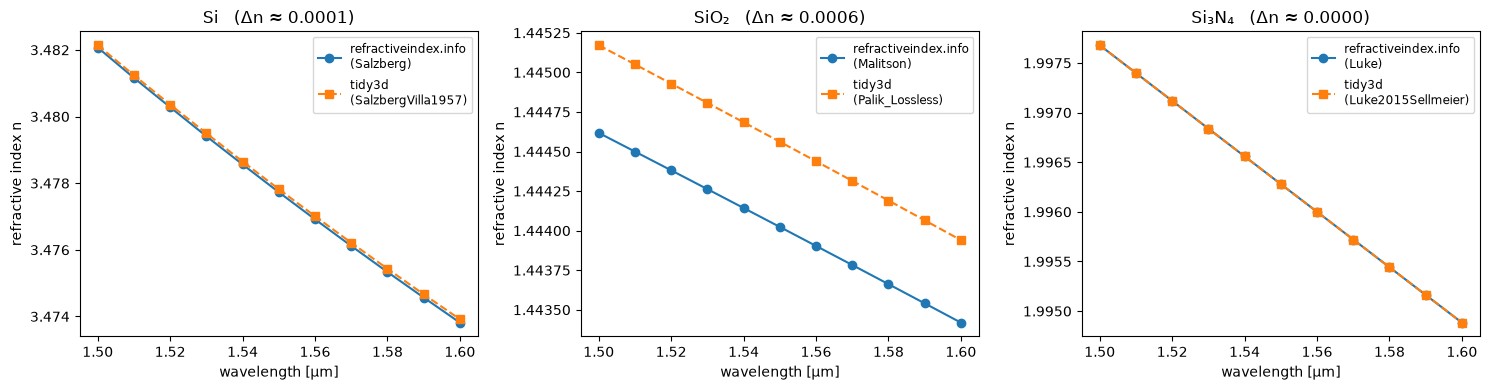

In [3]:
import tidy3d as td  # noqa: E402

# (rii shelf/book/page) vs (tidy3d library book/variant), matched by source
COMPARISONS = {
    "Si": (("main", "Si", "Salzberg"), ("cSi", "SalzbergVilla1957")),
    "SiO₂": (("main", "SiO2", "Malitson"), ("SiO2", "Palik_Lossless")),
    "Si₃N₄": (("main", "Si3N4", "Luke"), ("Si3N4", "Luke2015Sellmeier")),
}


def rii_n(book_page, wl):
    shelf, book, page = book_page
    m = load_rii_material(shelf, book, page, db_dir=str(RII_DB))
    return np.array([complex(m.nk_at(w)).real for w in wl])


def td_n(book_variant, wl):
    book, variant = book_variant
    med = td.material_library[book][variant]
    return np.array([float(med.nk_model(td.C_0 / w)[0]) for w in wl])


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (rii_ref, td_ref)) in zip(axes, COMPARISONS.items(), strict=True):
    n_rii = rii_n(rii_ref, WL)
    n_td = td_n(td_ref, WL)
    ax.plot(WL, n_rii, "o-", label=f"refractiveindex.info\n({rii_ref[2]})")
    ax.plot(WL, n_td, "s--", label=f"tidy3d\n({td_ref[1]})")
    ax.set_title(f"{name}   (Δn ≈ {np.max(np.abs(n_rii - n_td)):.4f})")
    ax.set_xlabel("wavelength [µm]")
    ax.set_ylabel("refractive index n")
    ax.legend(fontsize="small")
fig.tight_layout()
plt.show()

The refractiveindex.info data and the engines' bundled models lie on top of
each other — agreement to a few parts in ten-thousand. So you can source *any*
material from refractiveindex.info and trust it will behave like the vendor
model, on any engine.

## 3 · The gotcha: a material is not one number

Silicon nitride is the cautionary tale. "Si₃N₄" spans a whole family — LPCVD
stoichiometric nitride sits near n ≈ 2.0, while higher-nitrogen PECVD films
(e.g. the "Horiba" model) run ~0.4 higher. Picking the wrong one is a ~0.4
index error before you even mesh. Always match the model to *your* fab.

17:18:21 PDT WARNING: frequency passed to 'Medium.eps_model()'is outside of     
             'Medium.frequency_range' = (362698386340789.0, 1329894083249559.8) 

             WARNING: frequency passed to 'Medium.eps_model()'is outside of     
             'Medium.frequency_range' = (362698386340789.0, 1329894083249559.8) 

             WARNING: frequency passed to 'Medium.eps_model()'is outside of     
             'Medium.frequency_range' = (362698386340789.0, 1329894083249559.8) 

             WARNING: frequency passed to 'Medium.eps_model()'is outside of     
             'Medium.frequency_range' = (362698386340789.0, 1329894083249559.8) 

             WARNING: frequency passed to 'Medium.eps_model()'is outside of     
             'Medium.frequency_range' = (362698386340789.0, 1329894083249559.8) 

...

             WARNING: frequency passed to 'Medium.eps_model()'is outside of     
             'Medium.frequency_range' = (362698386340789.0, 1329894083249559.8) 

             WARNING: frequency passed to 'Medium.eps_model()'is outside of     
             'Medium.frequency_range' = (362698386340789.0, 1329894083249559.8) 

             WARNING: frequency passed to 'Medium.eps_model()'is outside of     
             'Medium.frequency_range' = (362698386340789.0, 1329894083249559.8) 

             WARNING: frequency passed to 'Medium.eps_model()'is outside of     
             'Medium.frequency_range' = (362698386340789.0, 1329894083249559.8) 

             WARNING: frequency passed to 'Medium.eps_model()'is outside of     
             'Medium.frequency_range' = (362698386340789.0, 1329894083249559.8) 

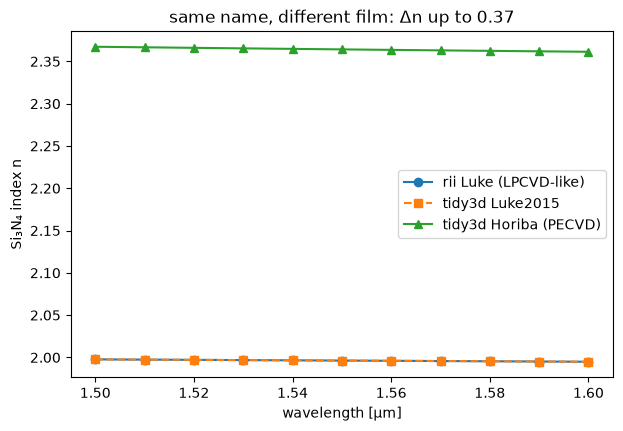

In [4]:
n_luke_rii = rii_n(("main", "Si3N4", "Luke"), WL)
n_luke_td = td_n(("Si3N4", "Luke2015Sellmeier"), WL)
n_horiba = td_n(("Si3N4", "Horiba"), WL)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(WL, n_luke_rii, "o-", label="rii Luke (LPCVD-like)")
ax.plot(WL, n_luke_td, "s--", label="tidy3d Luke2015")
ax.plot(WL, n_horiba, "^-", label="tidy3d Horiba (PECVD)")
ax.set_xlabel("wavelength [µm]")
ax.set_ylabel("Si₃N₄ index n")
ax.set_title(f"same name, different film: Δn up to {np.max(n_horiba - n_luke_rii):.2f}")
ax.legend()
plt.show()

## 4 · What each engine does with dispersion

tidy3d and Lumerical model the **full n(λ)** curve. **beamz v1** uses a single
constant index (the material's neutral `nk`) — fine for a narrow band, but it
does not disperse. The technology's neutral `nk` is exactly that flat value:

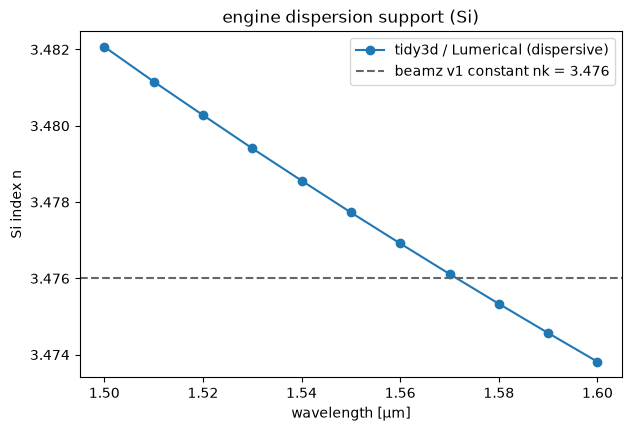

In [5]:
n_si_dispersive = rii_n(("main", "Si", "Salzberg"), WL)
n_si_neutral = resolve_index(tech.device[0].material, 1.55).real  # beamz v1 uses this constant
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(WL, n_si_dispersive, "o-", label="tidy3d / Lumerical (dispersive)")
ax.axhline(n_si_neutral, ls="--", color="0.4", label=f"beamz v1 constant nk = {n_si_neutral:.3f}")
ax.set_xlabel("wavelength [µm]")
ax.set_ylabel("Si index n")
ax.set_title("engine dispersion support (Si)")
ax.legend()
plt.show()

## Recap & next

- One technology YAML feeds every engine; materials carry a neutral index plus
  optional refractiveindex.info and per-engine references.
- refractiveindex.info data agrees with the engines' shipped models to <0.001
  — source materials from it with confidence.
- Match the *variant* to your process (the Si₃N₄ trap), and remember beamz v1
  is single-index.

**Next:** `03_first_simulation` puts this technology to work end to end.